# Taller Bono Individual — Métodos Matemáticos
## Sergio Alejandro Pinzón Salomón — 202411038

---

### 1.3 Visualización de Armónicos Esféricos $Y_l^m$


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm

In [39]:
# Visualización de Armónicos Esféricos Y_l^m

# Se representan en coordenadas 3D donde el radio r = |Re(Y_l^m)| determina
# la forma del lóbulo y el color representa el signo de la parte real:
#   - Rojo  : Y_l^m > 0
#   - Azul  : Y_l^m < 0
# Esta representación permite visualizar directamente el número de nodos angulares de cada modo.



theta = np.linspace(0, np.pi, 500)
phi   = np.linspace(0, 2 * np.pi, 500)
THETA, PHI = np.meshgrid(theta, phi)


def graficar_armonico(l, m, ax, titulo):
    """
    Grafica el armónico esférico real Y_l^m en un eje 3D.

    Parámetros
    ----------
    l     : int     número multipolar (grado),
    m     : int     número azimutal (orden),   
    ax    : Axes3D  eje de matplotlib con proyección 3D
    titulo: str     etiqueta que aparece sobre la figura

    Procedimiento
    -------------
    1. Se calcula la parte real de Y_l^m sobre la grilla (THETA, PHI).
    2. El radio r = |Re(Y)| se usa para deformar la esfera unidad:
         x = r * sin(theta) * cos(phi)
         y = r * sin(theta) * sin(phi)
         z = r * cos(theta)
    3. El color se asigna normalizando Re(Y) en [0,1] y aplicando
       el mapa RdBu (rojo=positivo, azul=negativo).
    """
    # Parte real del armónico esférico
    Y = sph_harm(m, l, PHI, THETA).real

    # Radio proporcional al valor absoluto
    r = np.abs(Y)

    # Conversión a coordenadas esfericas
    X  = r * np.sin(THETA) * np.cos(PHI)
    Y_ = r * np.sin(THETA) * np.sin(PHI)
    Z  = r * np.cos(THETA)

    # Normalización global del color en [0, 1]
    Y_norm = (Y - Y.min()) / (Y.max() - Y.min())

    ax.plot_surface(X, Y_, Z,facecolors=plt.cm.RdBu(Y_norm),alpha=0.95)
    ax.set_title(titulo, fontsize=11)
    ax.set_axis_off()


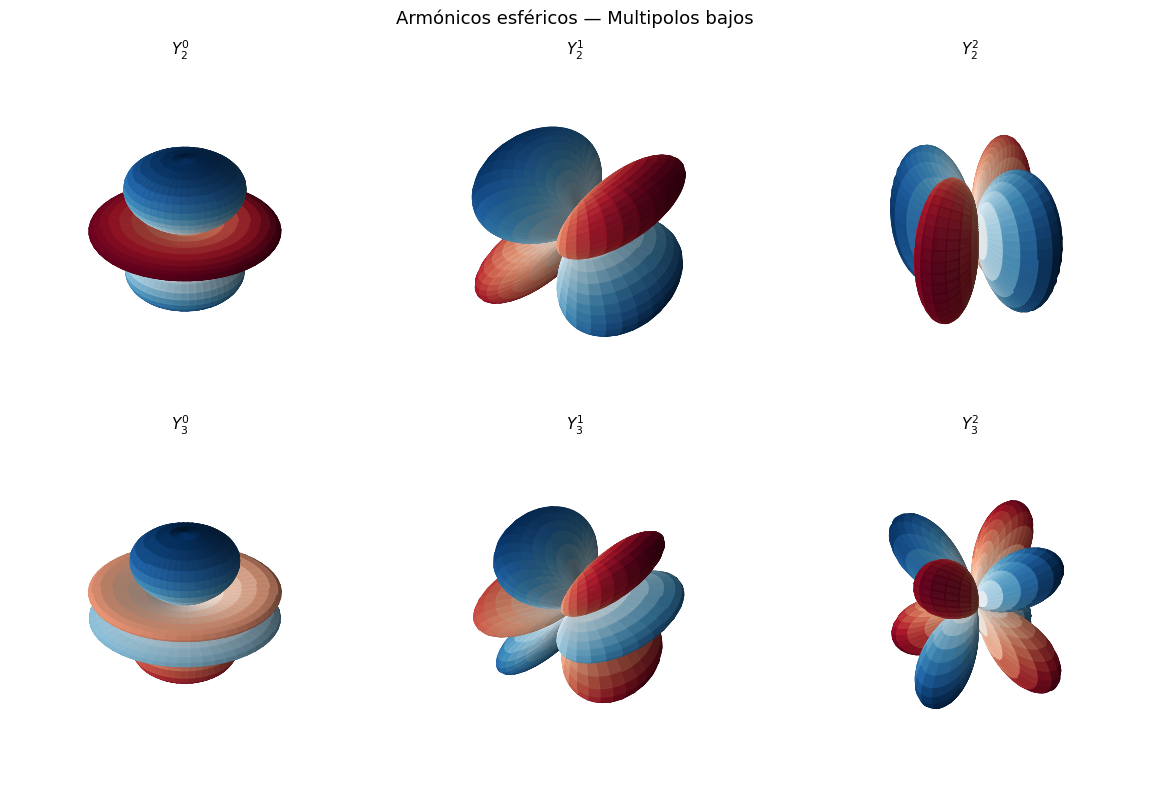

In [40]:
# Figura 1: Multipolos bajos (l = 2, 3)
# Pocos lóbulos de gran tamaño angular -> estructuras de gran escala en el CMB

casos_bajos = [
    (2,  0, r'$Y_2^0$'),   # cuadrupolo, simetría axial
    (2,  1, r'$Y_2^1$'),   # cuadrupolo, forma de x
    (2,  2, r'$Y_2^2$'),   # cuadrupolo, 4 lóbulos 
    (3,  0, r'$Y_3^0$'),   # octupolo, simetría axial
    (3,  1, r'$Y_3^1$'),   # octupolo, x de 6 puntas 
    (3,  2, r'$Y_3^2$'),   # octupolo, estructura mixta
]


fig1, axes1 = plt.subplots(2, 3, figsize=(12, 8),
                            subplot_kw={'projection': '3d'})
fig1.suptitle('Armónicos esféricos — Multipolos bajos', fontsize=13)

for ax, (l, m, label) in zip(axes1.flatten(), casos_bajos):
    graficar_armonico(l, m, ax, label)

plt.tight_layout()
plt.savefig('armonicos_bajos.png', dpi=150, bbox_inches='tight')
plt.show()



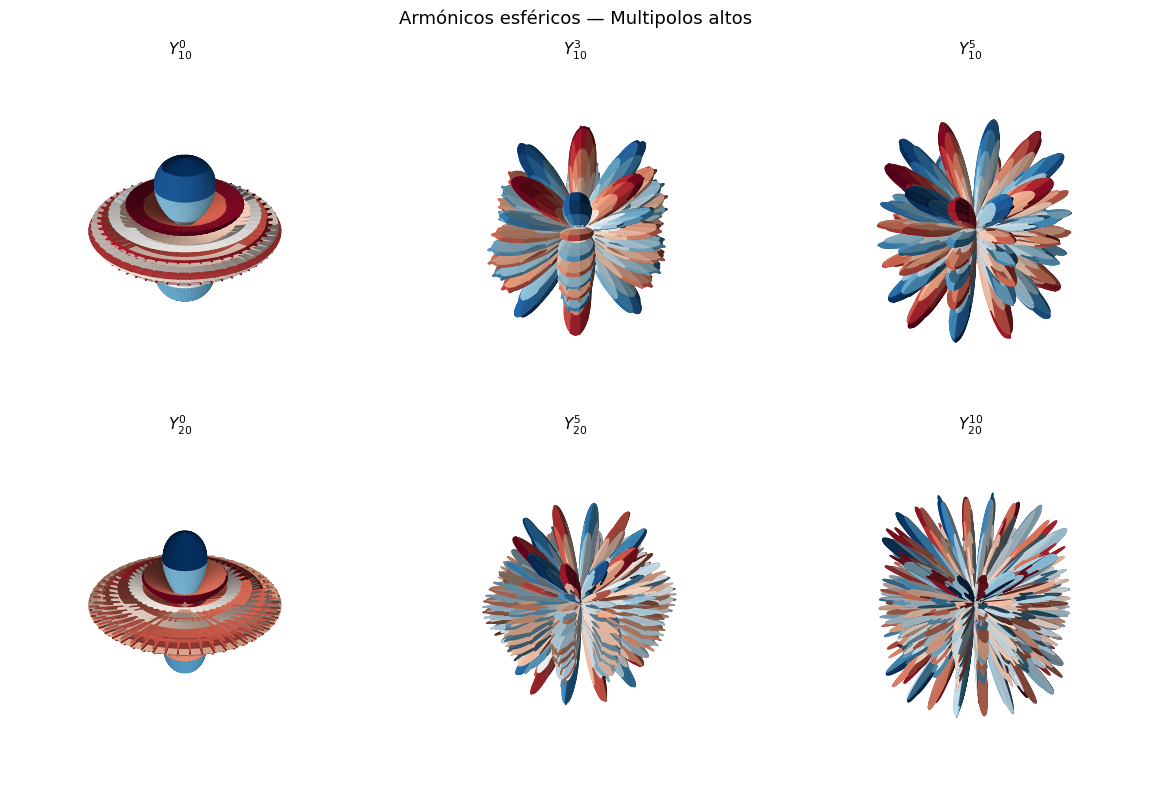

In [41]:
# Figura 2: Multipolos altos (l = 10, 20)
# Muchos lóbulos de pequeño tamaño angular -> estructuras finas en el CMB

casos_altos = [
    (10,  0, r'$Y_{10}^0$'),    # muchos anillos, simetría axial
    (10,  3, r'$Y_{10}^3$'),    # combinación de anillos y pétalos
    (10,  5, r'$Y_{10}^5$'),    # patrón de pétalos finos
    (20,  0, r'$Y_{20}^0$'),    # aún más anillos
    (20,  5, r'$Y_{20}^5$'),    # pétalos intermedios
    (20, 10, r'$Y_{20}^{10}$'), # estructura muy densa
]

fig2, axes2 = plt.subplots(2, 3, figsize=(12, 8),
                            subplot_kw={'projection': '3d'})
fig2.suptitle('Armónicos esféricos — Multipolos altos', fontsize=13)

for ax, (l, m, label) in zip(axes2.flatten(), casos_altos):
    graficar_armonico(l, m, ax, label)

plt.tight_layout()
plt.savefig('armonicos_altos.png', dpi=150, bbox_inches='tight')
plt.show()

### 2. Funciones de Neumann $N_n(x)$